In [21]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("K-Means model and scaler saved successfully!")

K-Means model and scaler saved successfully!


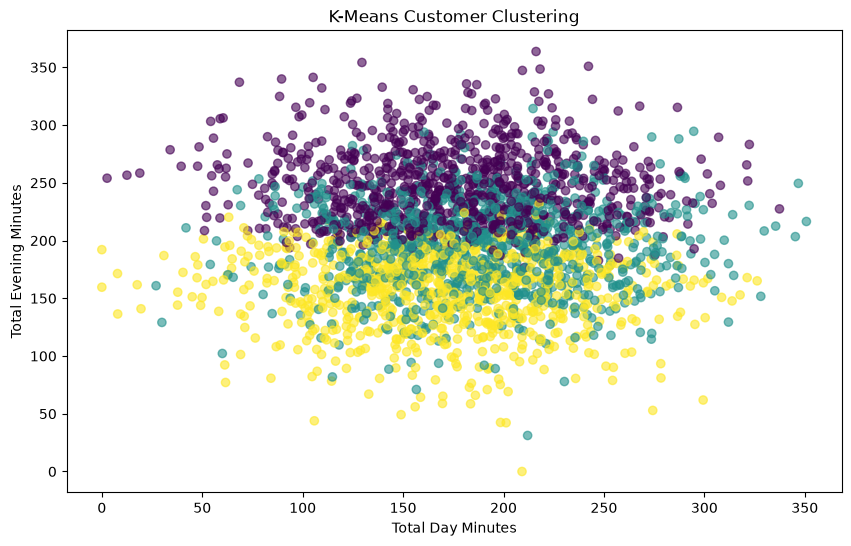

Scatter plot saved successfully!


In [20]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Total day minutes"],
    df["Total eve minutes"],
    c=df["Cluster"],
    alpha=0.6
)

plt.xlabel("Total Day Minutes")
plt.ylabel("Total Evening Minutes")
plt.title("K-Means Customer Clustering")

plt.savefig("kmeans_clusters.png", dpi=300, bbox_inches="tight")

plt.show()

print("Scatter plot saved successfully!")

In [19]:
df["Cluster"] = kmeans.fit_predict(X_scaled)
df.to_csv("kmeans_clustering_results.csv", index=False)

print("Clustering results saved successfully!")

Clustering results saved successfully!


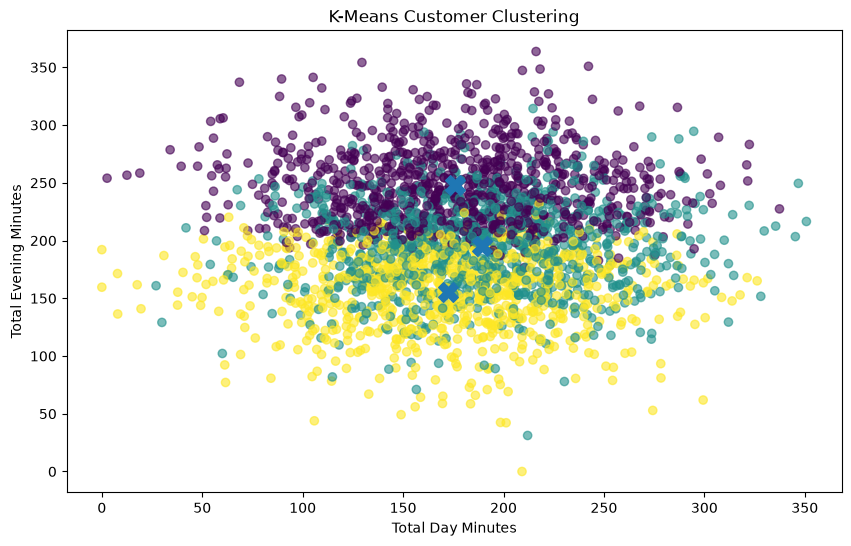

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("churn-bigml-80.csv")

# Select features
features = [
    "Account length",
    "Number vmail messages",
    "Total day minutes",
    "Total day calls",
    "Total day charge",
    "Total eve minutes",
    "Total eve calls",
    "Total eve charge",
    "Total night minutes",
    "Total night calls",
    "Total night charge",
    "Total intl minutes",
    "Total intl calls",
    "Total intl charge",
    "Customer service calls"
]

# Remove missing values
df = df.dropna(subset=features)

# Prepare data
X = df[features]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

# Get cluster centers in original units
centers = scaler.inverse_transform(kmeans.cluster_centers_)

# Find column positions
day_index = features.index("Total day minutes")
eve_index = features.index("Total eve minutes")

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Total day minutes"],
    df["Total eve minutes"],
    c=df["Cluster"],
    alpha=0.6
)

# Plot cluster centers
plt.scatter(
    centers[:, day_index],
    centers[:, eve_index],
    marker="X",
    s=200
)

plt.xlabel("Total Day Minutes")
plt.ylabel("Total Evening Minutes")
plt.title("K-Means Customer Clustering")
plt.show()

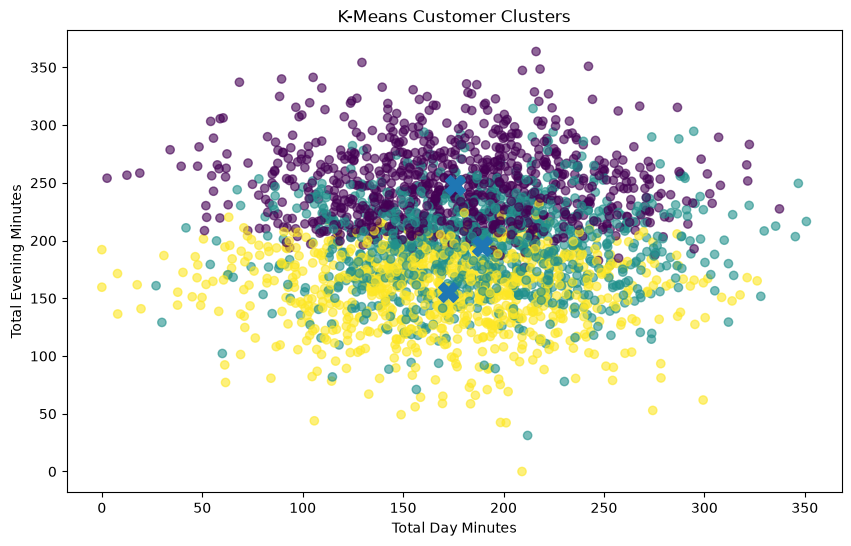

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot customers
plt.scatter(
    df["Total day minutes"],
    df["Total eve minutes"],
    c=df["Cluster"],
    alpha=0.6
)

# Get cluster centers and convert them back to original scale
centers = scaler.inverse_transform(kmeans.cluster_centers_)

# Positions of the two features
day_index = features.index("Total day minutes")
eve_index = features.index("Total eve minutes")

# Plot cluster centers
plt.scatter(
    centers[:, day_index],
    centers[:, eve_index],
    marker="X",
    s=200
)

plt.xlabel("Total Day Minutes")
plt.ylabel("Total Evening Minutes")
plt.title("K-Means Customer Clusters")
plt.show()

In [15]:
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [14]:
cluster_summary = df.groupby("Cluster")[features].mean()

print(cluster_summary)

         Account length  Number vmail messages  Total day minutes  \
Cluster                                                             
0            100.314254               7.894501         175.647138   
1             98.387821               8.679487         189.274679   
2            103.436234               7.423123         172.628486   

         Total day calls  Total day charge  Total eve minutes  \
Cluster                                                         
0              99.773288         29.860617         247.783838   
1             100.318376         32.177286         195.419872   
2             100.871275         29.347223         155.591299   

         Total eve calls  Total eve charge  Total night minutes  \
Cluster                                                           
0              98.722783         21.061919           176.310774   
1             101.077991         16.610855           249.893803   
2             100.228844         13.225554           173.209

In [13]:
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df["Cluster"].value_counts().sort_index())

Cluster
0    891
1    936
2    839
Name: count, dtype: int64


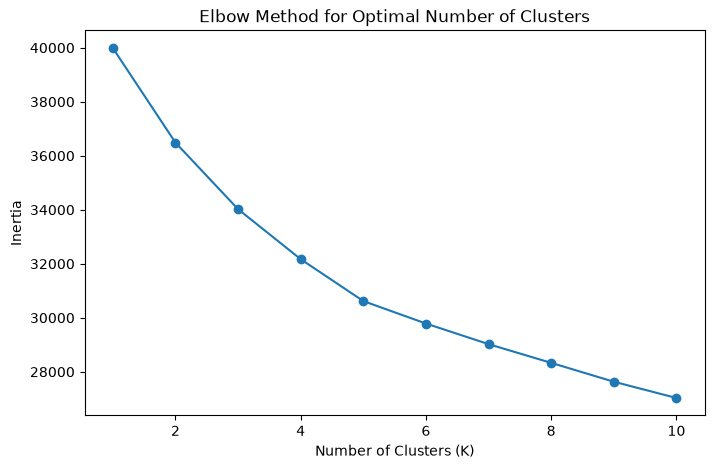

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

In [11]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

In [10]:
df = pd.read_csv("churn-bigml-80.csv")

features = [
    "Account length",
    "Number vmail messages",
    "Total day minutes",
    "Total day calls",
    "Total day charge",
    "Total eve minutes",
    "Total eve calls",
    "Total eve charge",
    "Total night minutes",
    "Total night calls",
    "Total night charge",
    "Total intl minutes",
    "Total intl calls",
    "Total intl charge",
    "Customer service calls"
]

X = df[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [8]:
standardized_df.to_csv(
    "standardized_customer_data.csv",
    index=False
)

print("Standardized dataset saved successfully!")

Standardized dataset saved successfully!


In [7]:
print("Means:")
print(standardized_df.mean())

print("\nStandard deviations:")
print(standardized_df.std())

Means:
Account length           -1.292623e-16
Number vmail messages    -2.665202e-17
Total day minutes         1.399231e-16
Total day calls           2.212117e-16
Total day charge         -2.198791e-16
Total eve minutes        -1.119385e-16
Total eve calls           3.104960e-16
Total eve charge          2.811788e-16
Total night minutes       5.996704e-16
Total night calls        -2.198791e-17
Total night charge       -3.038330e-16
Total intl minutes       -2.038879e-16
Total intl calls         -5.930073e-17
Total intl charge         5.250447e-16
Customer service calls   -5.596923e-17
dtype: float64

Standard deviations:
Account length            1.000188
Number vmail messages     1.000188
Total day minutes         1.000188
Total day calls           1.000188
Total day charge          1.000188
Total eve minutes         1.000188
Total eve calls           1.000188
Total eve charge          1.000188
Total night minutes       1.000188
Total night calls         1.000188
Total night charge   

In [6]:
standardized_df = pd.DataFrame(
    X_scaled,
    columns=features
)

print(standardized_df.head())

   Account length  Number vmail messages  Total day minutes  Total day calls  \
0        0.692163               1.247508           1.579670         0.484868   
1        0.161278               1.320985          -0.329918         1.135375   
2        0.919686              -0.589414           1.179302         0.685024   
3       -0.420168              -0.589414           2.212509        -1.466653   
4       -0.647691              -0.589414          -0.235822         0.634985   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0          1.579942          -0.058619        -0.050781         -0.058445   
1         -0.330194          -0.095916         0.147654         -0.095397   
2          1.179465          -1.554439         0.494917         -1.554963   
3          2.212675          -2.718509        -0.596479         -2.718922   
4         -0.235772          -1.022461         1.090224         -1.021482   

   Total night minutes  Total night calls  Total night c

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Dataset standardized successfully!")

Dataset standardized successfully!


In [4]:
features = [
    "Account length",
    "Number vmail messages",
    "Total day minutes",
    "Total day calls",
    "Total day charge",
    "Total eve minutes",
    "Total eve calls",
    "Total eve charge",
    "Total night minutes",
    "Total night calls",
    "Total night charge",
    "Total intl minutes",
    "Total intl calls",
    "Total intl charge",
    "Customer service calls"
]

X = df[features]

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("churn-bigml-80.csv")

print(df.head())
print(df.shape)

  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1             27.47   

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans